> Notebook-friendly copy of `part-I/1.4-matplotlib-and-xarray-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

In [1]:
# --- environment setup (generated, not part of the lesson) ---
# Colab and Kaggle do not ship every package this notebook imports.
# This is a no-op in an environment that is already set up.
import importlib.util
import subprocess
import sys

for module, package in {"pooch": "pooch"}.items():
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# Exercises

**ℹ️ How to use these exercises**

Attempt each from scratch in the empty code cell. Run the shared setup cell below first — exercises 1 to 11 all use the synthetic station records it builds. Label every axis with its unit.

The last four exercises work differently: each shows a figure made from a real dataset and asks you to rebuild it. Get as close as you can, and read the hints one at a time rather than all at once.

In [2]:
# Pre-supplied: run this first. Three synthetic station records and a humidity series,
# standing in for a year of daily weather observations.
import numpy as np
import matplotlib.pyplot as plt

In [3]:
rng = np.random.default_rng(1)

In [4]:
days = np.arange(366)                                  # day of year, 2024 (a leap year)
seasonal_celsius = -np.cos(2 * np.pi * days / 366) * 10.0

In [5]:
valley_celsius = 6.0 + seasonal_celsius + rng.normal(0, 1.5, size=366)
ridge_celsius = valley_celsius - 6.5                   # ~1000 m higher
mountain_celsius = valley_celsius - 18.0               # ~2800 m higher

In [6]:
# humidity peaks about a month after the coldest day, so it lags temperature
rh_percent = 68.0 + 12.0 * np.cos(2 * np.pi * (days - 30) / 366) + rng.normal(0, 3.0, size=366)

In [7]:
print(valley_celsius.shape, rh_percent.shape)

(366,) (366,)


## Exercise 1: Placing axes by hand

Build a 7 × 3 inch figure with two axes positioned with `fig.add_axes`: a main panel covering
roughly the left two-thirds, and a smaller one in the upper right. Plot the valley station's
whole year in the main panel and January alone (`days[:31]`) in the small one. Label the axes of
both, and give the small panel a title.

<Axes: >

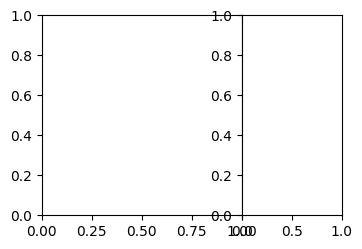

In [40]:
import matplotlib.pyplot as plt

# plot
fig = plt.figure(figsize=(7,3))
fig.add_axes([0,0,2/7,2/3])
fig.add_axes([2/7,0,1/7,2/3])




## Exercise 2: A grid of panels

With `plt.subplots(2, 2, figsize=(9, 5))`, give each of the three station records and the
humidity series its own panel. Print the shape of the axes array, label every panel with its
quantity and unit, give each a title, and pack the figure with `tight_layout`.

In [9]:
# Your solution here

## Exercise 3: Telling series apart without colour

Plot all three station records on one axes so that they stay distinguishable printed in black
and white: all three in black, one solid, one dashed, one dotted. Then add every thirtieth point
of the valley record as circular markers with no line joining them. Add a legend.

In [10]:
# Your solution here

## Exercise 4: Ticks, gridlines, and axis limits

Plot the valley record, then:

1. Replace the x ticks with `["Jan", "Apr", "Jul", "Oct", "Jan"]` at days `[0, 90, 180, 270, 365]`.
2. Put major y ticks every 5 °C and minor ones every 1 °C, with a solid major grid and a dotted
   minor grid.
3. In a second figure, show only days 150 to 240, with the y-axis limited to 5 to 25 °C.

In [11]:
# Your solution here

## Exercise 5: Annotate the extremes

Find the warmest and the coldest day of the valley record with `np.argmax` and `np.argmin`. Mark
each on the plot with `ax.annotate` and an arrow, and add a plain `ax.text` label somewhere in
the summer half of the year.

In [12]:
# Your solution here

## Exercise 6: A parametric plot

Average both the valley record and the humidity series into twelve monthly means with
`[:360].reshape(12, 30).mean(axis=1)`, then plot humidity against temperature with a marker at
each month. Label both axes. The twelve points trace a loop rather than a line — add a one-line
comment saying what that loop tells you about the two quantities.

In [13]:
# Your solution here

## Exercise 7: Scatter and histogram

Make a 1 × 2 figure. On the left, scatter humidity against temperature, with point colour mapped
to day of year (labelled colorbar) and point size mapped to each day's absolute departure from
the annual mean temperature. On the right, a 24-bin histogram of the temperature. Label every
axis.

In [14]:
# Your solution here

## Exercise 8: Bar and barh

Compute the annual mean of each of the three stations and compare them in a 1 × 2 figure: `bar`
on the left, `barh` on the right. Label the value axis with its unit in both.

In [15]:
# Your solution here

## Exercise 9: One field, three ways

Build the small gridded field below, then draw it three times in a 1 × 3 figure: with `imshow`
(row 0 is the southernmost latitude, so make it appear at the bottom), with `pcolormesh` using
the coordinates, and with `contourf` using 8 levels. Label the `imshow` panel's axes in grid
index and the other two in degrees — the difference is the point of the exercise. Give each panel
a labelled colorbar, and save the figure as `_files/field.svg`.

```python
lon = np.linspace(6.0, 9.0, 6)
lat = np.linspace(46.0, 47.5, 4)      # ascending: south -> north
field_celsius = 6.0 + (46.0 - lat)[:, None] * 3.0 + rng.normal(0, 1.0, size=(4, 6))
```

In [16]:
# Your solution here

## Exercise 10: A vector field

Build the synthetic wind field below — a simple rotation, like a cyclone seen from above — and
draw it two ways in a 1 × 2 figure. On the left, `quiver` at every third grid point, over
`contour` lines of the wind speed. On the right, `streamplot` coloured by wind speed, with a
labelled colorbar. Label the axes in km.

```python
x_km = np.linspace(-100, 100, 25)
y_km = np.linspace(-100, 100, 25)
xx_km, yy_km = np.meshgrid(x_km, y_km)
u_ms = -yy_km / 8.0
v_ms = xx_km / 8.0
```

In [17]:
# Your solution here

## Exercise 11: Fix the figure

The cell below draws thirty days (days 120 to 149) of the valley and ridge records, and breaks
most of the best-practices checklist at the end of the lecture. First list every practice it
breaks, as comments. Then redraw the same data so that it passes all of them.

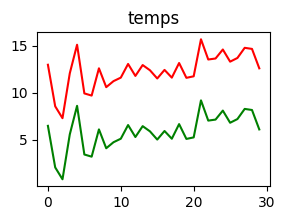

In [18]:
# Pre-supplied: a figure that breaks most of the checklist.
# Leave this cell as it is -- write the corrected version in the next one.
fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(valley_celsius[120:150], color="red")
ax.plot(ridge_celsius[120:150], color="green")
ax.set_title("temps")
plt.show()

In [19]:
# Your solution here

## Exercise 12: Build a labelled DataArray

From `data = np.arange(12.0).reshape(3, 4)`, build an xarray DataArray with dimensions
`("lat", "lon")`, latitude coordinates `[46.0, 46.5, 47.0]`, longitude coordinates
`[6.0, 6.5, 7.0, 7.5]`, and a `units` attribute of `"degC"`. Print its dims and its units.

In [20]:
# Your solution here

## Exercise 13: Select and reduce

Build the small Dataset below, then print the spatial mean of the first day (by position) and the
time mean at latitude 47.0 (by label).

```python
rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2024-01-11", dtype="datetime64[D]")
lat = np.array([46.0, 46.5, 47.0]); lon = np.array([6.0, 6.5, 7.0, 7.5])
t = rng.normal(5, 3, size=(10, 3, 4))
ds = xr.Dataset({"t2m": (("time", "lat", "lon"), t)},
                coords={"time": time, "lat": lat, "lon": lon})
```

In [21]:
# Your solution here

## Exercise 14: Resample and a monthly climatology

Build a one-year daily temperature DataArray (construction below), compute its monthly means
with `resample`, print how many there are, then use `groupby` to find the warmest calendar month
(1–12).

```python
rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2025-01-01", dtype="datetime64[D]")
n = time.size; doy = np.arange(n)
t = 5 + -np.cos(2 * np.pi * doy / n) * 10 + rng.normal(0, 1.5, n)
da = xr.DataArray(t, dims="time", coords={"time": time}, attrs={"units": "degC"})
```

In [22]:
# Your solution here

## Exercise 15: Round-trip through netCDF

Create a 1D temperature DataArray named `t2m` with a `units` attribute, write it to
`_files/series.nc`, reopen it with `open_dataset`, and print the variable names and the recovered
units.

In [23]:
# Your solution here

## Exercise 16: A field on a map with cartopy

Rebuild the DataArray `da` from exercise 12. Plot it on a `ccrs.PlateCarree()` projection with
`.coastlines()` and a labelled colorbar, using `transform=ccrs.PlateCarree()`.

In [24]:
# Your solution here

## Exercise 17: NASA's real global-temperature record

The file cached below is NASA GISS's monthly global-mean surface temperature anomaly (°C,
relative to a 1951–1980 baseline), one row per year since 1880, one column per calendar month.
A handful of recent months are still missing, marked `***`.

1. Load it with
   `np.genfromtxt(path, skip_header=1, delimiter=",", names=True, missing_values="***", filling_values=np.nan)`.
   Stack the twelve month columns (`data["Jan"]`, ..., `data["Dec"]`) into a `(year, month)` array
   with `np.column_stack`.
2. Wrap it in an xarray `DataArray` with dims `("year", "month")`, coordinates `year` (from
   `data["Year"]`) and `month` (`np.arange(1, 13)`), and a `units` attribute of `"degC"`.
3. Plot the annual mean (`.mean(dim="month")`, which skips the missing months automatically) as a
   line against year.
4. Plot the full `(year, month)` DataArray directly with `.plot()` — xarray draws it as a labelled
   `pcolormesh`. Compare what the warming trend looks like read month by month against the single
   annual line.

In [25]:
# Pre-supplied: download the data file and cache it locally.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/nasa_gistemp_global_temp_anomaly.csv",
    known_hash="sha256:6cfa44e7bbacd9b12cb10bdd64b3182c2735fa3f3a95688e1f7bc8e5dfcece93",
    fname="nasa_gistemp_global_temp_anomaly.csv",
    path=pooch.os_cache("mlees"),
)

In [26]:
# Your solution here

## Replicating plots

The four exercises below each show a figure built from a real dataset and ask you to rebuild it
as closely as you can. The data arrive through a pre-supplied `pooch` cell; everything after that
is yours.

Work towards the target one element at a time — get the data onto the axes first, then the
coordinates, then the colours, then the labels — rather than trying to write the whole cell in
one go.

## Exercise 18: Global surface air temperature and its zonal mean

The three files cached below hold one snapshot of surface air temperature from the
[NCEP/NCAR atmospheric reanalysis 1](https://psl.noaa.gov/data/gridded/data.ncep.reanalysis.html),
as plain numpy arrays: `lon` (192 longitudes), `lat` (94 latitudes, running north to south), and
`temp_kelvin`, the field itself with shape `(94, 192)` — **in kelvin**.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-global-temperature.png" alt="A filled contour map of global surface air temperature in magma colours with a white dashed contour at minus ten degrees, beside a line plot of the zonal mean against latitude" width="100%">

<em>The figure to replicate. Left: the field as filled contours, with a single white contour drawn
at −10 °C. Right: the zonal mean — the average along longitude — against latitude.</em>


1. Load the three arrays with `np.load` and convert the temperature to degrees celsius.
2. Build the two panels with
   `plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [5, 1.5]})` — `width_ratios`
   is what makes the left panel wider than the right one.
3. Draw the field with `contourf`, `cmap="magma"`, `levels=np.linspace(-30, 40, 15)` and
   `extend="both"`, then overlay `contour` at `levels=[-10]` with `colors="w"`. matplotlib dashes
   a contour at a negative level on its own, which is where the dashed white line comes from.
4. The right panel is the mean along the longitude axis, plotted against latitude — so the
   temperature goes on the *x*-axis. `np.nanmean(temp_celsius, axis=1)` gives it.
5. Label both panels and the colorbar, and finish with `plt.tight_layout()`.
6. In a comment, say which hemisphere's winter this snapshot was taken in, and how the zonal mean
   tells you.

In [27]:
# Pre-supplied: download the three arrays and cache them locally.
import pooch

In [28]:
base_url = "https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/"

In [29]:
path_lon = pooch.retrieve(
    url=base_url + "ncep_global_temp_lon.npy",
    known_hash="sha256:eaf54b88dd89279d3034da17fe8470dc2c841bf9fa89b2aa741dacff9c326cdb",
    fname="ncep_global_temp_lon.npy",
    path=pooch.os_cache("mlees"),
)
path_lat = pooch.retrieve(
    url=base_url + "ncep_global_temp_lat.npy",
    known_hash="sha256:af1f438080460e1fca4583b2ec19b44285a3d3776e4d21b8da9b6e162906c88a",
    fname="ncep_global_temp_lat.npy",
    path=pooch.os_cache("mlees"),
)
path_temp = pooch.retrieve(
    url=base_url + "ncep_global_temp_kelvin.npy",
    known_hash="sha256:e040ca257334708b43e86398e09a5669fcf051179ecf5dcd278f758d67beed20",
    fname="ncep_global_temp_kelvin.npy",
    path=pooch.os_cache("mlees"),
)

In [30]:
# Your solution here

## Exercise 19: Historic significant earthquakes

The file cached below is NOAA's catalog of significant earthquakes, reaching back to 2150 BCE:
one row per event, tab-separated, 47 columns. The four you need are at positions 8
(`FOCAL_DEPTH`, km), 9 (`EQ_PRIMARY`, magnitude), 20 (`LATITUDE`) and 21 (`LONGITUDE`).

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-earthquakes-scatter.png" alt="A scatter plot of earthquake longitude against latitude, coloured by the base-10 logarithm of focal depth and sized by magnitude" width="100%">

<em>The figure to replicate: every event as one point, coloured by the base-10 logarithm of its
focal depth and sized by its magnitude. No coastline is drawn — the plate boundaries are the
data.</em>


1. Load the whole file with `np.genfromtxt(path, delimiter="\t", skip_header=1)` and pull out
   the four columns by position. Every non-numeric field becomes `NaN`, which is what you want
   here.
2. Keep only the rows where depth and magnitude are both above zero and latitude and longitude
   are not `NaN`. Build one boolean mask for all four conditions: `&` combines two masks
   element-wise ("and"), and `~` flips one ("not"), so `~np.isnan(latitude)` is True wherever
   the latitude is present.
3. Scatter longitude against latitude, with colour mapped to `np.log10` of the focal depth — the
   base-10 logarithm, applied element-wise, which spreads out depths running from under a
   kilometre to several hundred — and point area to the square of the magnitude. Add a labelled
   colorbar, axis labels, a title, and a dotted grid.
4. In a comment, name the feature of the Earth that the empty regions of the plot trace out.

In [31]:
# Pre-supplied: download the data file and cache it locally.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/signif.txt.tsv",
    known_hash="sha256:f27e00d335f64ffaf437e74a8efb54f9154d40b417ff93fefb0fd64856e6d345",
    fname="signif.txt.tsv",
    path=pooch.os_cache("mlees"),
)

In [32]:
# Your solution here

## Exercise 20: Antarctic sea ice, summer against winter

Two real snapshots of Antarctic sea ice concentration from NOAA/NSIDC are cached below, as
`path_winter` (1 August 2017) and `path_summer` (31 December 2017). Each holds
`seaice_conc_cdr`, the ice concentration as a fraction from 0 to 1, on a south polar
stereographic grid — its coordinates are 2D `latitude`/`longitude` arrays rather than simple 1D
dimensions, so xarray's own `.plot()` will not label it cleanly.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-seaice.png" alt="Two south polar stereographic maps of Antarctic sea ice concentration, one in austral winter with a wide ice ring and one in austral summer with much less ice" width="100%">

<em>The figure to replicate: the same field on the same projection at two dates, with the land drawn
in grey beneath the ice and one colorbar shared by both panels.</em>


Rebuild it, and say which date shows more ice.

In [33]:
# Pre-supplied: download the data files and cache them locally.
import pooch

path_winter = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/seaice_conc_daily_sh_f17_20170801_v03r01.nc",
    known_hash="sha256:1ff50bca1e6249a9b2fcd9d9466e31bdb5be650243f99c7319ab2ce625b87ce7",
    fname="seaice_conc_daily_sh_f17_20170801_v03r01.nc",
    path=pooch.os_cache("mlees"),
)
path_summer = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/seaice_conc_daily_sh_f17_20171231_v03r01.nc",
    known_hash="sha256:309418969ad09f42b8104589bcb86de4ed353a5742fef9385baec174c7d55e66",
    fname="seaice_conc_daily_sh_f17_20171231_v03r01.nc",
    path=pooch.os_cache("mlees"),
)

In [34]:
# Your solution here
# Hint: open each file with xr.open_dataset and select the single time step with .isel(time=0)
# Hint: the valid concentration range is 0-1; a few cells carry flag values above 1
#       (land, coastal, missing) -- mask them out first with da.where(da <= 1)
# Hint: build a figure with two ccrs.SouthPolarStereo() axes:
#       plt.subplots(1, 2, subplot_kw={"projection": ccrs.SouthPolarStereo()})
# Hint: ax.set_extent([-180, 180, -90, -55], ccrs.PlateCarree()) crops each axes to the
#       Southern Ocean instead of the whole hemisphere
# Hint: since latitude/longitude are 2D, plot with
#       ax.pcolormesh(ds["longitude"], ds["latitude"], masked, transform=ccrs.PlateCarree())
#       rather than xarray's own .plot()
# Hint: add cfeature.LAND under the data, gridlines, and one labelled colorbar for both panels

## Exercise 21: The 2014 earthquakes over North America

The file cached below is the real USGS earthquake catalog for 2014 — one row per event
worldwide, with latitude, longitude, depth and magnitude in columns 1 to 4. The target figure
keeps the whole catalog and lets the map extent do the selecting, so what you see is a window
onto a global dataset rather than a filtered one.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-earthquakes-map.png" alt="A Robinson-projection map of North America with state boundaries, lakes and rivers, and earthquake locations coloured by depth" width="90%">

<em>The figure to replicate: magnitude 4 and above, on a Robinson projection cropped to North and
Central America, over land, ocean, lake, river and state-boundary features.</em>


Rebuild it.

In [35]:
# Pre-supplied: download the data file and cache it locally.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/usgs_earthquakes_2014.csv",
    known_hash="sha256:84d455fb96dc8f782fba4b5fbe56cb8970cab678f07c766fcba1b1c4674de1b1",
    fname="usgs_earthquakes_2014.csv",
    path=pooch.os_cache("mlees"),
)

In [36]:
# Your solution here
# Hint: load the four numeric columns with
#       np.genfromtxt(path, delimiter=",", skip_header=1, usecols=(1, 2, 3, 4))
#       -- usecols skips the text columns (time, place, ...) mixed in with the numbers
# Hint: keep mag >= 4 and depth_km > 0 (a few events are recorded at exactly 0 km, which
#       np.log10 cannot take); combine the two conditions into one mask with & ("and")
# Hint: fig, ax = plt.subplots(subplot_kw={"projection": ccrs.Robinson()})
# Hint: ax.set_extent([-140, -60, 12, 70], ccrs.PlateCarree()) crops to the window shown
# Hint: the features are cfeature.LAND, cfeature.OCEAN, cfeature.LAKES, cfeature.RIVERS and
#       cfeature.STATES; add_feature takes edgecolor, facecolor and linewidth, and STATES
#       reads better in gray at a thin linewidth
# Hint: ax.scatter(longitude, latitude, transform=ccrs.PlateCarree(),
#                  c=np.log10(depth_km), s=mag ** 2)
#       -- transform tells cartopy the coordinates are plain lon/lat, not already projected
# Hint: finish with ax.gridlines, a labelled colorbar, and a title